In [1]:
%load_ext autoreload
%autoreload 2

# **Feature Extraction**

El punto de partida del proyecto es un modelo que tome simplemente características numéricas de cada época (lapso de 30 segundos) e intente realizar una predicción a partir de estos. Para ello se realizó un proceso de *feature extraction* en el que, para cada época, se recortan las muestras de IHR y de acelerometría que caen en esa ventana de 30 s y se calculan las features descritas abajo.

Un punto importante sobre la **acelerometría**: features por cada eje (`x`, `y`, `z`) por separado dependen de la **orientación** del reloj (una persona acostada de lado vs. boca arriba da valores distintos aunque esté igual de quieta). Por eso todas las features de movimiento se calculan sobre la **magnitud del vector** $\|a\| = \sqrt{x^2+y^2+z^2}$, que es invariante a la orientación.

## Features *intra-época*

**IHR (Instantaneous Heart Rate):** Generamos features que son utilizadas en la práctica en el análisis de variabilidad de la frecuencia cardíaca (HRV, Heart Rate Variability) en el dominio del tiempo. Conceptos base:

- Intervalo *RR*: el tiempo (ms) entre dos latidos consecutivos, reconstruido como $\text{RR}=\tfrac{60.000\text{ms}}{\text{bpm}}$
- Intervalo *NN*: "nortmal-to-normal" interval, mismos intervalos que RR pero filtrando latidos irregulares (arritmias o errores del sensor). 

| Feature | Definición | Qué captura |
|---|---|---|
| `hr_mean` | Media del IHR. | Frecuencia cardíaca típica de la época. |
| `hr_std` | Desvío estándar (≈ SDNN=Standard Deviation of NN). | Variabilidad cardíaca global. |
| `hr_median` | Mediana. | Nivel central robusto ante outliers del IHR. |
| `hr_iqr` | Rango intercuartil (P75 − P25). | Dispersión robusta, alternativa a `std`. |
| `hr_rmssd` | "Root Means Square of Successive Differences". Raíz del promedio de las diferencias sucesivas al cuadrado, sobre intervalos RR (RR = 60000/bpm).| HRV de corto plazo / tono parasimpático. |
| `hr_pnn50` | "Percent of NN intervals differing by more than 50ms". Fracción de diferencias NN sucesivas mayores a 50 ms.| Otro índice de HRV vagal; complementa a `rmssd`. |
| `hr_slope` | Pendiente de la regresión lineal del IHR vs. tiempo dentro de la época. | Tendencia: aceleración o desaceleración cardíaca. |
| `hr_ptp` | Rango pico a pico. | Amplitud total de fluctuación; sensible a saltos de IHR. |
| `n_beats` | Cantidad de latidos válidos en la época. | Densidad de muestreo del IHR (no es uniforme); puede correlacionar con la calidad/estado. |

**Acelerometría (sobre la magnitud $\|a\|=\sqrt{x^2+y^2+z^2}$):**

*ENMO* (Euclidean Norm Minus One): se le resta $1g$ ($\approx 9.8m/s^2$) a la magnitud de la aceleración $\|a\|$ para quitar la gravedad y truncar a $>=0$. El estándar de oro en **actigrafía** para cuantificar movimiento neto.

$$
\text{ENMO} = \max (\|a\|- 1,\ 0)
$$

| Feature | Definición | Qué captura |
|---|---|---|
| `enmo_mean` | Media de ENMO. | Media de la aceleración dinámica neta. |
| `enmo_std` | Desvío estándar de ENMO. | Variabilidad del movimiento dentro de la época. |
| `acc_std` | Desvío estándar de $\|a\|$. | Cuánto fluctúa la magnitud; proxy de agitación. |
| `acc_ptp` | Rango pico a pico de $\|a\|$. | Amplitud máxima de movimiento. |
| `immobility_frac` | Fracción de muestras con $\|\,\|a\|-1\,\| < 0.05$ g. | Grado de inmovilidad; alto en sueño profundo, bajo en vigilia. |
| `jerk_std` | Desvío de la derivada de $\|a\|$. ($\text{jerk}=\tfrac{da}{dt}$: tasa de cambio de la aceleración) | Brusquedad del movimiento (sacudidas vs. deriva lenta). |

**Contexto del paciente:**

| Feature | Definición | Qué captura |
|---|---|---|
| `epoch_frac` | Índice de época normalizado (época / total de la noche). | Momento de la noche: la arquitectura del sueño depende fuertemente de él. |

## Features *inter-épocas*

Un modelo por época ignora que el sueño es altamente autocorrelacionado (las transiciones siguen reglas: no se salta de N3 a vigilia, REM sigue a NREM, etc.). Para inyectarle ese contexto temporal de forma explícita (lo que el LSTM hace implícitamente), sobre cada feature base se agregan, **dentro de cada noche** (respetando los límites entre noches):

- **`_lag1`, `_lag2`, `_lead1`, `_lead2`**: el valor de la feature 1 y 2 épocas antes y después (±30 y ±60 s de contexto).
- **`_delta1`**: diferencia con la época previa (`x[t] − x[t−1]`); un salto grande marca una transición de estado.
- **`_rmean`, `_rstd`**: media y desvío en una ventana móvil centrada de 5 épocas (±2), que suavizan el ruido y describen la dinámica local.

Además, una feature global de movimiento:

- **`epochs_since_move`**: cantidad de épocas transcurridas desde el último movimiento grande (ENMO medio > 0.05 g); proxy de qué tan asentado está el sueño.

Los valores en los bordes (lags/leads sin vecino) quedan como `NaN`, que **XGBoost maneja de forma nativa** aprendiendo una dirección por defecto. El dataset resultante (`data/epoch_features.csv`) tiene una fila por época, identificada por `subject`, `night` y `epoch`, con la etiqueta del experto (`expert_label`) como `label`. El recorte de cada noche a su ventana válida se aplica en memoria vía `EDA.load_night_clean`, sin modificar los CSV originales.


In [2]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import f1_score, cohen_kappa_score
from xgboost import XGBClassifier, plot_importance

from src.lstm import ConfigLSTM, partition_subjects, collapse4_scores
from src.feature_extraction import feature_extraction
from src.metrics import print_metrics, plot_confusion, roc_pr_curves

# generar epoch_features.csv si no existe
FEATURES_PATH = "../data_extraction/epoch_features.csv"
if os.path.exists(FEATURES_PATH):
    print(f"{FEATURES_PATH} ya existe; se omite la extracción.")
else:
    feature_extraction()

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


../data_extraction/epoch_features.csv ya existe; se omite la extracción.


# **Split y entrenamiento del XGBoost**

Sobre el dataset de features entrenamos un **XGBoost** como modelo baseline (una predicción por época, sin secuencia).

**Partición de los datos.** Usamos **exactamente el mismo split por paciente que `model.ipynb`** (`partition_subjects` sobre `ConfigLSTM`: misma seed y fracciones), para que el baseline y los modelos secuenciales se evalúen sobre el **mismo test set**. La partición es **por paciente** (no por época): como las épocas de una misma noche/paciente están fuertemente correlacionadas, mezclarlas entre train y test produciría *fuga de información*. Como el baseline **no hace búsqueda de hiperparámetros**, no necesita un conjunto de validación: **train y val se unen** y el modelo se entrena con **train+val**, midiéndose en **test**.

**Etiquetas.** El target es la etiqueta del experto (`label`). Descartamos las épocas marcadas como *Unknown* (clase 5).

**Evaluación.** Reportamos **F1-Score (macro)** y **Cohen's Kappa** sobre el test, comparando las predicciones contra dos referencias:
- **Expert**: la etiqueta del experto, que es el target con el que se entrenó.
- **Dreem**: el etiquetado automático de Dreem (basado en EEG). No es el target; mide cuánto coincide el modelo con una segunda anotación independiente.


In [3]:
df = pd.read_csv("../data_extraction/epoch_features.csv")

# descartamos las épocas Unknown (clase 5) del target
df = df[df['label'] != 5].reset_index(drop=True)

meta_cols = ['subject', 'night', 'epoch', 'label', 'dreem']
feature_cols = [c for c in df.columns if c not in meta_cols]

# MISMO split por sujeto que model.ipynb (partition_subjects sobre ConfigLSTM).
# Sin búsqueda de hiperparámetros -> train y val se unen: se entrena con train+val y se mide en test.
cfg = ConfigLSTM()
subj = partition_subjects(df['subject'].unique(), cfg)
trainval = subj['train'] | subj['val']
train_mask = df['subject'].isin(trainval)
test_mask = df['subject'].isin(subj['test'])

X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, 'label'].values
X_test, y_test = df.loc[test_mask, feature_cols], df.loc[test_mask, 'label'].values
dreem_test = df.loc[test_mask, 'dreem'].values

print(f"épocas    -> train+val: {len(X_train)}  test: {len(X_test)}")
print(f"pacientes -> train+val: {len(trainval)}  test: {len(subj['test'])}")

épocas    -> train+val: 174444  test: 29494
pacientes -> train+val: 40  test: 7


## Entrenamiento

In [4]:
# sin búsqueda de hiperparámetros ni validación: entrena directo sobre train+val.
xgboost = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
)

xgboost.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

## Desempeño

Evaluamos sobre el conjunto de **test** con `classification_report`, que produce dos bloques distintos.

**Métricas por clase** (una fila por etapa, calculadas *one-vs-rest*: "esta clase vs. todo lo demás"):

- **Precision** $= \tfrac{TP}{TP + FP}$: de las épocas que el modelo *predijo* como esa clase, qué fracción era correcta. Penaliza los **falsos positivos**.
- **Recall** (sensibilidad) $= \tfrac{TP}{TP + FN}$: de las épocas que *realmente eran* de esa clase, qué fracción detectó el modelo. Penaliza los **falsos negativos**.
- **F1-score** $= 2\cdot\tfrac{P\cdot R}{P + R}$: media armónica de precision y recall. Las resume en un número; es alto solo si **ambas** lo son.
- **Support**: cantidad de épocas reales de esa clase en el test. No es una métrica, sino el tamaño de la clase: evidencia el **desbalance** (N2 $\gg$ N1).

**Resúmenes globales** (las tres filas finales, que NO son clases sino formas de agregar):

- **Accuracy** $= \tfrac{\text{aciertos}}{\text{total}}$: un único número global. Engaña bajo desbalance: está dominada por la clase mayoritaria (N2).
- **Macro avg**: promedio **simple** de las métricas por clase (cada clase pesa igual, sin importar su support). Es la métrica honesta bajo desbalance: la pésima detección de N1 la castiga fuerte.
- **Weighted avg**: promedio **ponderado por support** (las clases grandes pesan más); queda más cerca de la accuracy.

Además reportamos **Cohen's Kappa**, $\kappa = \tfrac{p_o - p_e}{1 - p_e}$, donde $p_o$ es el acuerdo observado y $p_e$ el esperado por azar. $\kappa = 0$ es azar puro y $\kappa = 1$ acuerdo perfecto. Es la métrica estándar en *sleep staging* porque descuenta el acierto trivial sobre la clase mayoritaria.

Comparamos contra dos referencias:
- **Expert**: el target de entrenamiento (etiqueta del experto humano).
- **Dreem**: anotación automática basada en EEG, independiente; mide el acuerdo con una segunda fuente (enmascarando sus épocas *Unknown*).

In [5]:
y_pred = xgboost.predict(X_test)

print_metrics(y_test, y_pred, name='XGBoost (test, vs Expert):')

# vs Dreem (segunda anotación independiente); descartamos sus épocas Unknown
mask = dreem_test != 5
print(f"\nvs Dreem  ->  F1-macro: {f1_score(dreem_test[mask], y_pred[mask], average='macro'):.3f}"
      f"   Kappa: {cohen_kappa_score(dreem_test[mask], y_pred[mask]):.3f}")

XGBoost (test, vs Expert):
              precision    recall  f1-score   support

        Wake     0.6908    0.5430    0.6080      3361
          N1     0.2078    0.0173    0.0319      2776
          N2     0.5320    0.5453    0.5386     11481
          N3     0.6324    0.5654    0.5971      5654
         REM     0.3675    0.5788    0.4496      6222

    accuracy                         0.5063     29494
   macro avg     0.4861    0.4500    0.4450     29494
weighted avg     0.5041    0.5063    0.4912     29494

Cohen's Kappa:  0.3244
F1 macro:       0.4450
F1 micro:       0.5063
Accuracy:       0.5063

vs Dreem  ->  F1-macro: 0.443   Kappa: 0.329


### Matriz de confusión y curvas ROC/PR

La **matriz de confusión** (5 clases) muestra con qué se confunde cada etapa (fuera de la diagonal, los errores). Las **curvas ROC/PR** van en esquema En esquema **one-vs-rest** (una curva por etapa), vía `roc_pr_curves` de `src/metrics.py` — la misma función que usan todos los modelos. La **ROC** (con su AUC) mide la capacidad de ranking por clase; la **Precision-Recall** (con su *Average Precision*) es más informativa bajo el desbalance.

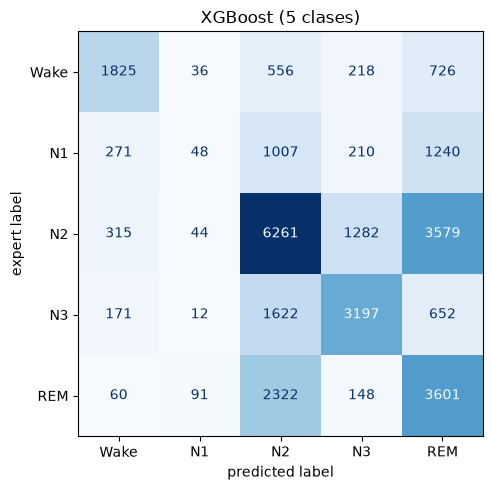

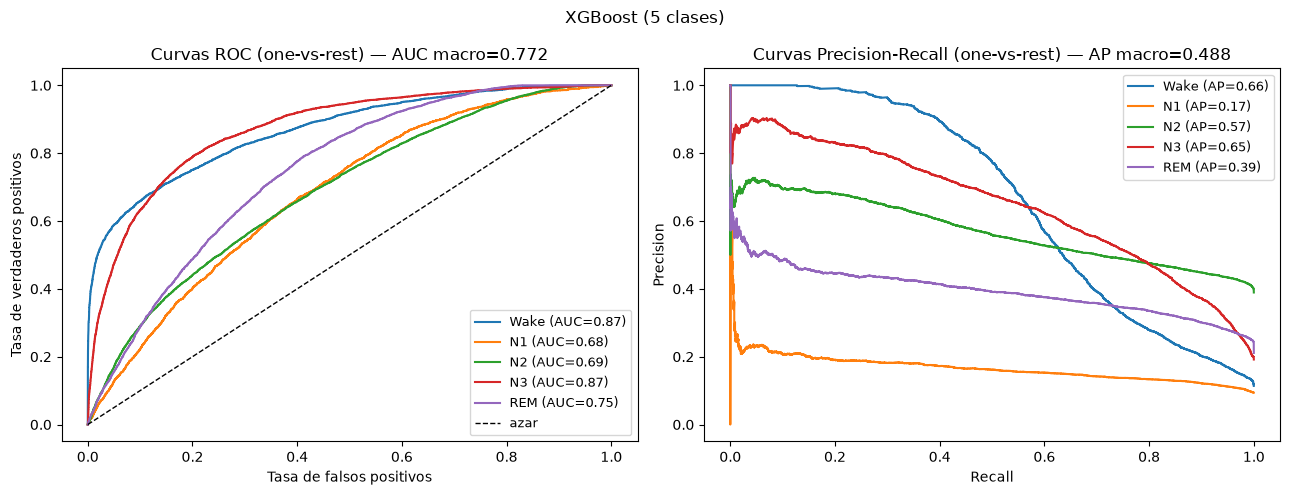

In [6]:
y_score_xgb = xgboost.predict_proba(X_test)

plot_confusion(y_test, y_pred, title='XGBoost (5 clases)', save='xgboost-confussion-5')
plt.show()

roc_pr_curves(y_test, y_score_xgb, title='XGBoost (5 clases)')
plt.show()

## Comparación en 4 clases (Wake / Light / Deep / REM)

El estándar AASM define 5 etapas (Wake, N1, N2, N3, REM), que es como entrenamos el modelo. Sin embargo, el **paper original del dataset** reporta sus métricas sobre **4 clases**, colapsando los estadios NREM. Para comparar nuestros resultados de forma justa con esa referencia, reagrupamos:

| 4 clases | Reúne (5 clases) | Qué representa |
|---|---|---|
| **Wake** | Wake | Vigilia. |
| **Light** | N1 + N2 | Sueño NREM superficial: transición a dormir (N1) y sueño consolidado ligero (N2). |
| **Deep** | N3 | Sueño de ondas lentas (*slow-wave sleep*); el más reparador. |
| **REM** | REM | Sueño de movimientos oculares rápidos. |

**Por qué tiene sentido (más allá de comparar con el paper):** la frontera N1/N2 es la más ambigua incluso entre expertos humanos (κ inter-anotador bajo), y N1 es una clase chica y difícil — justamente la que nuestro modelo casi no detecta (f1 ≈ 0.01). Colapsar N1+N2 en *Light* elimina esa distinción ruidosa y mide qué tan bien separamos los **macro-estados** fisiológicos (vigilia / ligero / profundo / REM), que es lo clínicamente relevante para un wearable.

Importante: **no reentrenamos**. Tomamos las predicciones del modelo de 5 clases y aplicamos el mismo mapeo a predicción y target; las métricas de 4 clases son una vista agregada del mismo modelo.

XGBoost 4 clases (test, vs Expert):
              precision    recall  f1-score   support

        Wake     0.6908    0.5430    0.6080      3361
       Light     0.6134    0.5162    0.5606     14257
        Deep     0.6324    0.5654    0.5971      5654
         REM     0.3675    0.5788    0.4496      6222

    accuracy                         0.5419     29494
   macro avg     0.5760    0.5509    0.5538     29494
weighted avg     0.5740    0.5419    0.5496     29494

Cohen's Kappa:  0.3363
F1 macro:       0.5538
F1 micro:       0.5419
Accuracy:       0.5419

vs Dreem (4 clases)  ->  F1-macro: 0.552   Kappa: 0.335


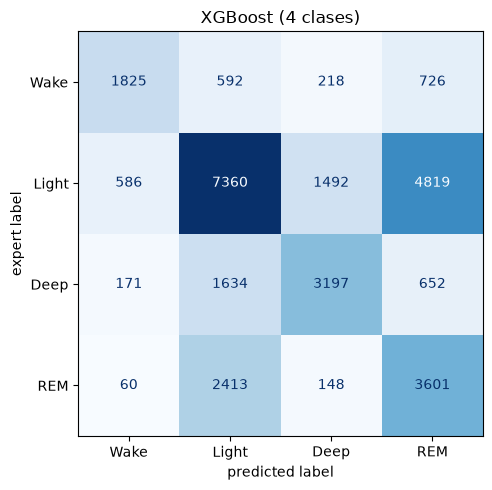

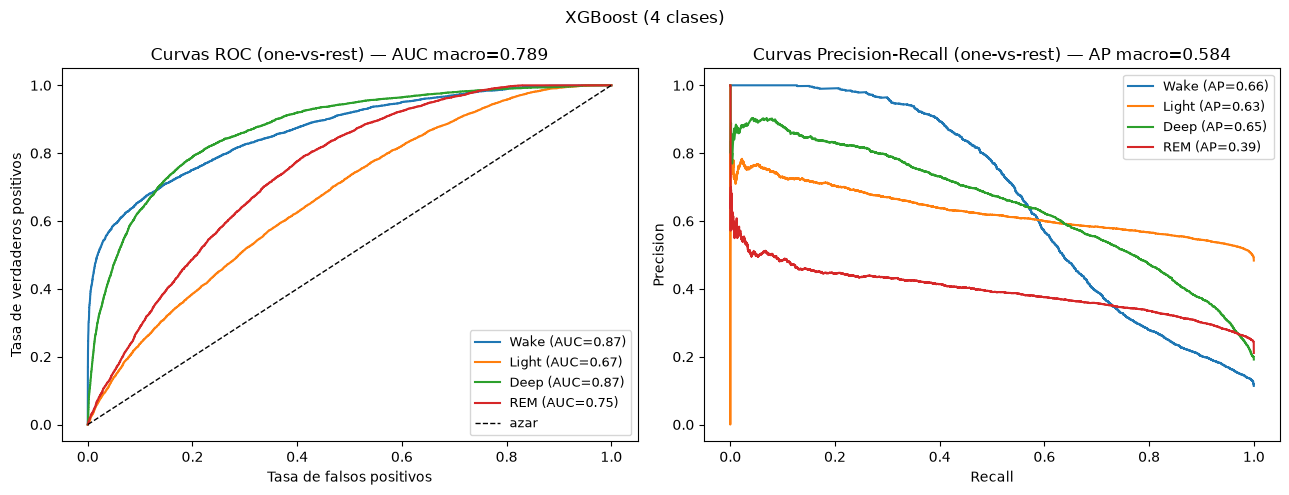

In [7]:
map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

y_test4 = remap(y_test)
y_pred4 = remap(y_pred)

print_metrics(y_test4, y_pred4, class_names=names4, name='XGBoost 4 clases (test, vs Expert):')

mask = dreem_test != 5
d4, p4 = remap(dreem_test[mask]), remap(y_pred[mask])
print(f"\nvs Dreem (4 clases)  ->  F1-macro: {f1_score(d4, p4, average='macro'):.3f}"
      f"   Kappa: {cohen_kappa_score(d4, p4):.3f}")

# matriz de confusión y curvas ROC/PR colapsadas a 4 clases (probabilidades sumadas por grupo NREM)
plot_confusion(y_test4, y_pred4, class_names=names4,
               title='XGBoost (4 clases)', save='xgboost-confussion-4')
plt.show()

roc_pr_curves(y_test4, collapse4_scores(y_score_xgb), class_names=names4,
              title='XGBoost (4 clases)')
plt.show()

# **Feature Importance**

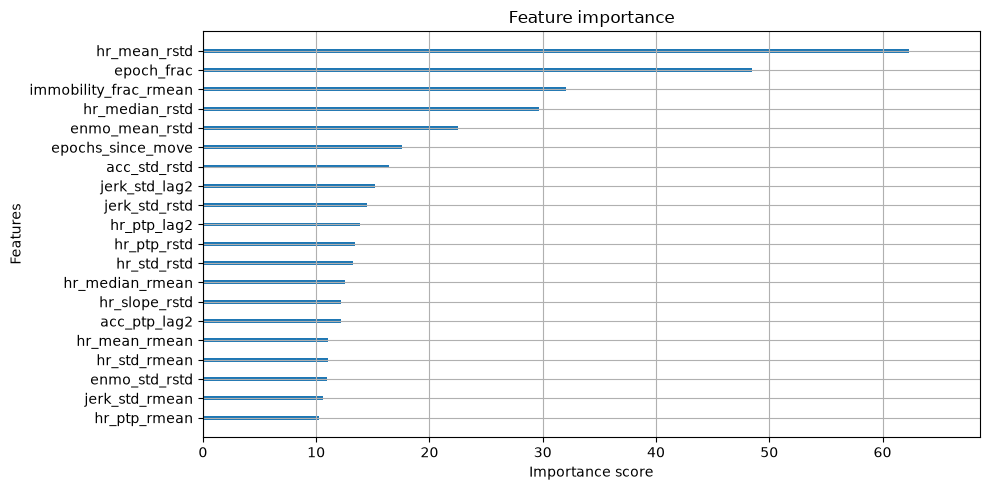

In [8]:
_, ax = plt.subplots(1,1,figsize=(10,5))
plot_importance(xgboost, ax=ax, importance_type='gain', max_num_features=20, show_values=False)
plt.tight_layout()
plt.show()

## Feature importance con SHAP

El `gain` de arriba tiene un problema con nuestras features: están muy **correlacionadas** (cada feature base genera `_lag/_lead/_delta/_rmean/_rstd`, y hay pares casi redundantes como `hr_mean`/`hr_median`). XGBoost reparte el `gain` de forma arbitraria entre features correlacionadas, así que ese ranking puede subestimar señales reales.

**SHAP** (*SHapley Additive exPlanations*) atribuye a cada feature su contribución marginal promedio a la predicción, con base teórica en los valores de Shapley de teoría de juegos. Ventajas para nuestro caso:

- Reparte mejor el crédito entre features correlacionadas.
- Da la importancia **por clase** (Wake / N1 / N2 / N3 / REM), no solo global: permite verificar la hipótesis fisiológica (HRV pesa en REM/N3, movimiento en Wake).

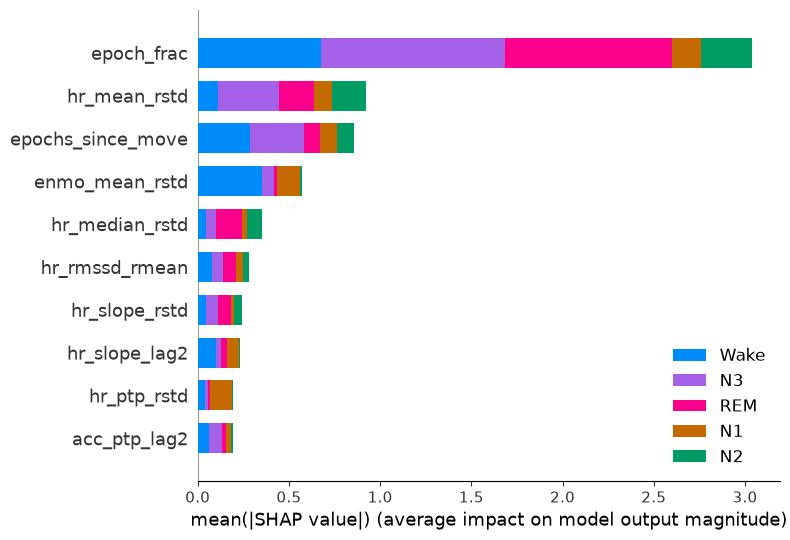

In [9]:
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

shap.summary_plot(shap_values, X_test, plot_type='bar', class_names=class_names, max_display=10, show=True)

En ambos enfoques (gain y SHAP) se destaca el índice de época (`epoch_frac`). Esto admite dos lecturas complementarias:

1. La arquitectura del sueño tiene una estructura temporal fuerte y aprendible a nivel poblacional: la etapa esperable depende mucho de la fracción de la noche (N3 domina el primer tercio, REM el último). El modelo explota este prior. Como contrapartida, apoyarse tanto en la posición (y no en la señal del reloj) implica un riesgo de peor generalización a noches atípicas, donde la arquitectura se desvía del promedio.
2. El posicionamiento temporal es clave, lo que sugiere que un modelo capaz de modelar dependencias temporales explícitas (LSTM/BiLSTM) sobre la secuencia de épocas debería mejorar las predicciones respecto del baseline por época.

Además, las features de contexto local (`_rmean`, `_rstd`, calculadas sobre ventanas de épocas vecinas) también figuran alto, lo que refuerza la misma idea: la información de las épocas adyacentes es relevante, y un modelo secuencial puede capturarla de forma nativa en lugar de tener que inyectarla a mano como features.

# **Red Neuronal Densa (MLP)**

Segundo modelo del baseline sobre las mismas features tabulares por época: una red densa (MLP) entrenada en PyTorch, comparada contra el XGBoost.

In [10]:
import sys
sys.path.append("..")

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

from src.mlp import MLP, get_dataloaders, train_model, predict, permutation_importance
from src.metrics import roc_pr_curves, print_metrics, plot_confusion

## Preprocesamiento y partición

Un MLP requiere dos pasos que preparan los datos tabulares:

1. **Imputación de NaN.** Las features de contexto (`_lag`, `_lead`, `_delta`, `_rmean`, `_rstd`) quedan como `NaN` en los bordes de cada noche. Una red densa propaga los `NaN`, así que se imputan con la **mediana** de cada feature, calculada **sobre train+val**.
2. **Estandarización.** Las features viven en escalas muy distintas (bpm, g, fracciones, conteos); un `StandardScaler` (media 0, desvío 1) evita que las de mayor magnitud dominen el gradiente. También **fiteado sobre train+val**.

**Partición.** El **mismo split por paciente que `model.ipynb`** (`partition_subjects` sobre `ConfigLSTM`). Como no hay búsqueda de hiperparámetros, **no se usa validación**: el MLP entrena con **train+val** y se mide en **test** (mismo test set que el XGBoost y los modelos secuenciales).

**Desbalance.** N2 domina y N1 es escasa. El parámetro `weight_mode` controla los pesos de clase de la loss. En esta corrida usamos **`weight_mode='none'`** (sin pesos): **maximiza accuracy y kappa** a costa del recall de las clases chicas (N1 casi no se detecta → baja el F1-macro). `'sqrt'` sería el punto intermedio y `'balanced'` el que prioriza el F1-macro.

In [11]:
train_loader, test_loader, class_weights, dreem_test, input_dim = get_dataloaders(
    batch_size=512, weight_mode="none"
)

CSV: ../data_extraction/epoch_features.csv
Features: 122 | train+val: 174444  test: 29494
Class weights (none): {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


## Arquitectura del MLP

Bloques densos `Linear -> BatchNorm -> ReLU -> Dropout` (256 -> 128 -> 64) y una capa final a las 5 etapas:

- **Entrada**: vector de features por época (`input_dim`).
- `BatchNorm1d` estabiliza el entrenamiento; `Dropout(0.3)` regulariza.
- **Salida**: 5 logits; la `CrossEntropyLoss` aplica el softmax internamente.

In [12]:
mlp = MLP(input_dim=input_dim, num_classes=5, hidden_dims=(256, 128, 64), dropout=0.3)
print(mlp)

MLP(
  (net): Sequential(
    (0): Linear(in_features=122, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=5, bias=True)
  )
)


## Entrenamiento

Optimizador **Adam**, loss **ponderada por clase** y **`ReduceLROnPlateau`** (baja el lr si la train loss se estanca). Como se entrena con **train+val** (sin validación), **no hay early stopping**: se corre un número **fijo** de epochs.

## Elección de hiperparámetros

La arquitectura y el entrenamiento se eligieron buscando un modelo **simple y bien regularizado**. En datos tabulares una red densa suele rendir a la par de los árboles de gradiente, y agregar capacidad tiende a **sobreajustar** antes que a mejorar la generalización, así que se priorizó la regularización sobre el tamaño.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Capas ocultas | 256 → 128 → 64 | Embudo que comprime las ~122 features a una representación cada vez más compacta. Profundidad moderada: alcanza para capturar interacciones no lineales sin la tendencia a sobreajustar de redes más profundas sobre datos tabulares. |
| Activación | ReLU | Estándar, barata y sin saturación en redes feedforward. |
| `BatchNorm1d` | en cada capa oculta | Normaliza las activaciones intermedias: estabiliza y acelera el entrenamiento, clave con features de escalas mixtas (bpm, g, conteos). |
| Dropout | 0.5 | Las features de contexto (`_lag`/`_lead`/`_rmean`…) están muy correlacionadas y la red sobreajusta fácil; el dropout la fuerza a no depender de neuronas puntuales. |
| Optimizador | Adam | Robusto y poco sensible al ajuste inicial del learning rate. |
| Learning rate | 5e-4 | Más chico que el default de Adam para suavizar la oscilación del val accuracy cerca del mínimo. |
| `weight_decay` | 1e-4 | L2 leve que penaliza pesos grandes, complementa al dropout. |
| `batch_size` | 512 | Con ~123k épocas de train; un batch más grande da un gradiente aún más estable (menos oscilación en validación). |
| Loss | CrossEntropy **(`none`)** | Dataset muy desbalanceado (N2 ≫ N1). En esta corrida sin pesos de clase, para maximizar accuracy y kappa (a costa del F1-macro / N1). El dial `weight_mode` admite `'balanced'`, `'sqrt'` o `'none'`. |
| Scheduler | `ReduceLROnPlateau` (patience 5, factor 0.5) | Cuando la train loss se estanca, baja el lr a la mitad para afinar con pasos más chicos. |
| Early stopping | — | Sin validación no aplica; se entrena con train+val por un número fijo de epochs. |
| `epochs` | 100 (fijo) | Entrena las 100 epochs completas (no hay corte por val). |

**Compromiso desbalance ↔ métricas.** Ponderar la loss mejora el *recall* de las clases chicas (sube el **F1-macro**) a costa de *accuracy* y *kappa*. El parámetro `weight_mode` controla ese dial: `'balanced'` (máximo F1-macro), `'sqrt'` (equilibrio) o `'none'` (máxima accuracy/kappa, usado acá).

In [13]:
mlp, history = train_model(
    model=mlp,
    train_loader=train_loader,
    class_weights=class_weights,
    epochs=100,
    lr=5e-4,
)

Epoch   1 | Train Loss: 1.2484
Epoch   2 | Train Loss: 1.1573
Epoch   3 | Train Loss: 1.1389
Epoch   4 | Train Loss: 1.1298
Epoch   5 | Train Loss: 1.1227
Epoch   6 | Train Loss: 1.1162
Epoch   7 | Train Loss: 1.1135
Epoch   8 | Train Loss: 1.1100
Epoch   9 | Train Loss: 1.1071
Epoch  10 | Train Loss: 1.1017
Epoch  11 | Train Loss: 1.0989
Epoch  12 | Train Loss: 1.0955
Epoch  13 | Train Loss: 1.0923
Epoch  14 | Train Loss: 1.0882
Epoch  15 | Train Loss: 1.0859
Epoch  16 | Train Loss: 1.0846
Epoch  17 | Train Loss: 1.0824
Epoch  18 | Train Loss: 1.0795
Epoch  19 | Train Loss: 1.0766
Epoch  20 | Train Loss: 1.0740
Epoch  21 | Train Loss: 1.0719
Epoch  22 | Train Loss: 1.0694
Epoch  23 | Train Loss: 1.0676
Epoch  24 | Train Loss: 1.0657
Epoch  25 | Train Loss: 1.0638
Epoch  26 | Train Loss: 1.0615
Epoch  27 | Train Loss: 1.0603
Epoch  28 | Train Loss: 1.0571
Epoch  29 | Train Loss: 1.0554
Epoch  30 | Train Loss: 1.0527
Epoch  31 | Train Loss: 1.0528
Epoch  32 | Train Loss: 1.0522
Epoch  3

### Curva de loss (train)

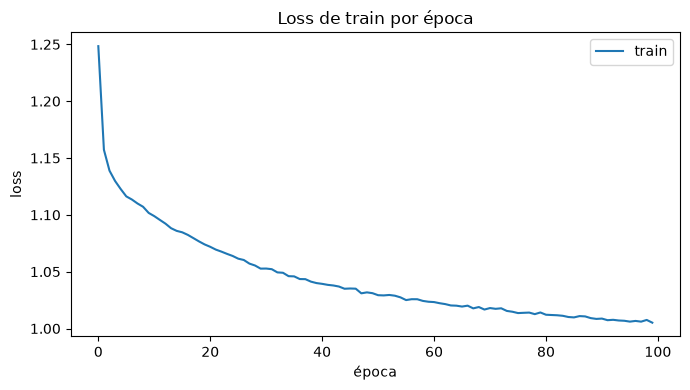

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train')
plt.xlabel('época')
plt.ylabel('loss')
plt.title('Loss de train por época')
plt.legend()
plt.tight_layout()
plt.show()

## Métricas en test

Sobre el conjunto de **test** reportamos **Accuracy**, **F1-score (macro)** y **Cohen's Kappa** de las predicciones contra la etiqueta del experto (el target). El F1-macro (promedio simple por clase) y el kappa (descuenta el acierto por azar sobre la mayoritaria) son las métricas honestas bajo desbalance.

Como **comparativa**, agregamos a **Dreem**: su etiquetado automático basado en EEG, evaluado también contra el Expert. Dreem es un dispositivo dedicado (mucho más informativo que HR + acelerometría), así que sus métricas funcionan como una **cota de referencia alta**. Para que sea justo, ambos se evalúan sobre las mismas épocas: aquellas donde Dreem produjo etiqueta (descartando sus *Unknown*).

In [15]:
y_true, y_pred = predict(mlp, test_loader)

def resumen(nombre, y_t, y_p):
    acc = accuracy_score(y_t, y_p)
    f1 = f1_score(y_t, y_p, average='macro')
    kappa = cohen_kappa_score(y_t, y_p)
    print(f"{nombre:20} Accuracy {acc:.3f} | F1-macro {f1:.3f} | Kappa {kappa:.3f}")

resumen("MLP (test completo)", y_true, y_pred)

mask = dreem_test != 5
print(f"\nComparativa vs Expert (épocas con Dreem válido: {mask.sum()} de {len(mask)}):")
resumen("  MLP", y_true[mask], y_pred[mask])
resumen("  Dreem", y_true[mask], dreem_test[mask])

MLP (test completo)  Accuracy 0.525 | F1-macro 0.450 | Kappa 0.347

Comparativa vs Expert (épocas con Dreem válido: 29412 de 29494):
  MLP                Accuracy 0.526 | F1-macro 0.451 | Kappa 0.348
  Dreem              Accuracy 0.792 | F1-macro 0.708 | Kappa 0.717


## Desglose por clase

Los agregados (accuracy, F1-macro, kappa) esconden *dónde* falla el modelo. El `classification_report` muestra **precision, recall y F1 por etapa**. El F1-macro (0.48) por debajo de la accuracy (0.53) ya anticipa que hay clases flojas — típicamente **N1**, la minoritaria y más ambigua.

In [16]:
print_metrics(y_true, y_pred, name='MLP (test, vs Expert):')

MLP (test, vs Expert):
              precision    recall  f1-score   support

        Wake     0.7472    0.5091    0.6056      3361
          N1     0.2857    0.0007    0.0014      2776
          N2     0.5509    0.5727    0.5616     11481
          N3     0.6131    0.5867    0.5996      5654
         REM     0.3932    0.6226    0.4820      6222

    accuracy                         0.5248     29494
   macro avg     0.5180    0.4584    0.4500     29494
weighted avg     0.5270    0.5248    0.5044     29494

Cohen's Kappa:  0.3473
F1 macro:       0.4500
F1 micro:       0.5248
Accuracy:       0.5248


## Matriz de confusión (5 clases)

Muestra con qué se confunde cada etapa: fuera de la diagonal están los errores (N1↔N2, N2↔N3, REM↔Wake…).

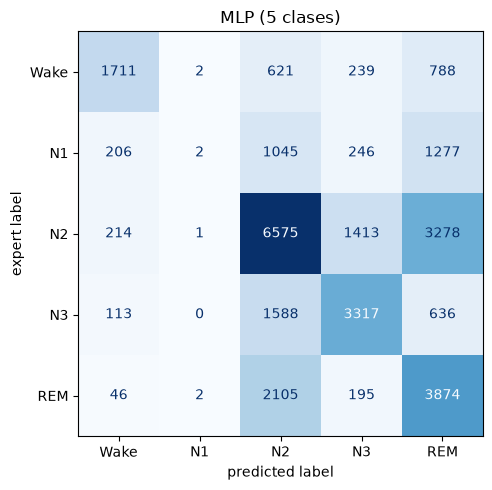

In [17]:
plot_confusion(y_true, y_pred, title='MLP (5 clases)', save='mlp-confussion-5')
plt.show()

## Curvas ROC y Precision-Recall

Al ser un problema multiclase, se grafican en esquema **one-vs-rest**: una curva por etapa. La **ROC** (TPR vs. FPR, con su AUC) resume la capacidad de ranking del modelo por clase, mientras que la **Precision-Recall** (con su *Average Precision*) es más informativa bajo el fuerte desbalance porque no premia el acierto trivial de la clase negativa mayoritaria. Se espera ver curvas pobres en **N1** (la clase marginal, casi no detectada) y mejores en Wake/N3/REM.

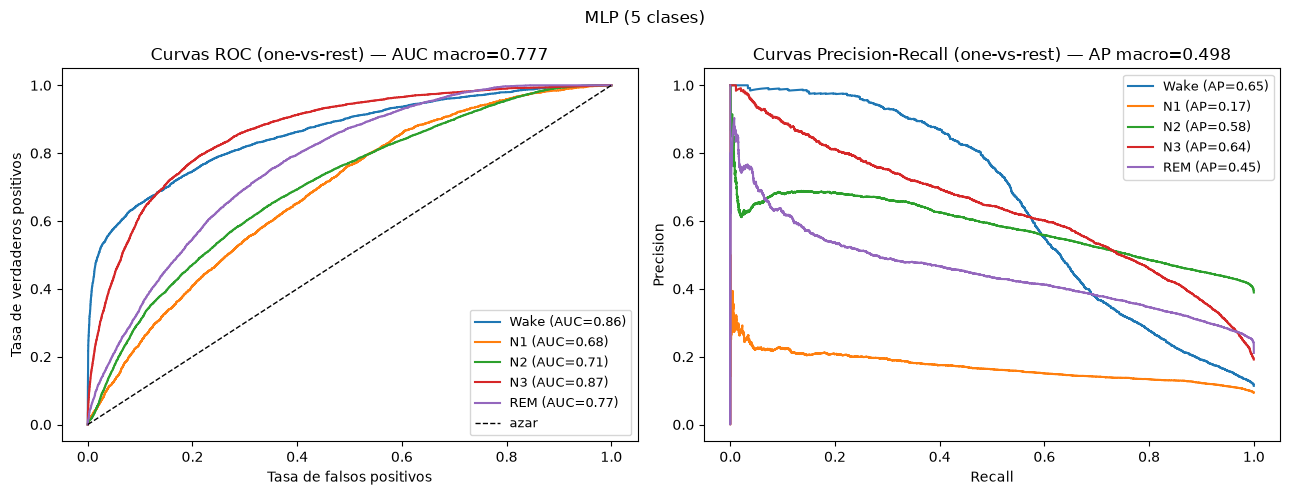

In [18]:
@torch.no_grad()
def predict_proba(model, loader, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device).eval()
    probs = [torch.softmax(model(X.to(device)), dim=1).cpu().numpy() for X, _ in loader]
    return np.concatenate(probs)

y_score = predict_proba(mlp, test_loader)
roc_pr_curves(y_true, y_score, title='MLP (5 clases)')
plt.show()

## Vista de 4 clases (Wake / Light / Deep / REM)

Colapsamos las etapas NREM (**N1+N2 → Light**, **N3 → Deep**) para comparar de forma justa con el paper del dataset (que reporta 4 clases) y con los otros notebooks (baseline y LSTM). La frontera N1/N2 es la más ambigua incluso entre expertos, así que colapsarla mide qué tan bien separamos los macro-estados fisiológicos. **No se reentrena**: se aplica el mismo mapeo a predicciones y target.

MLP (4 clases)
              precision    recall  f1-score   support

        Wake     0.7472    0.5091    0.6056      3361
       Light     0.6384    0.5347    0.5820     14257
        Deep     0.6131    0.5867    0.5996      5654
         REM     0.3932    0.6226    0.4820      6222

    accuracy                         0.5603     29494
   macro avg     0.5980    0.5633    0.5673     29494
weighted avg     0.5942    0.5603    0.5669     29494

Cohen's Kappa:  0.3626
F1 macro:       0.5673
F1 micro:       0.5603
Accuracy:       0.5603

vs Dreem (4 clases)  ->  F1-macro: 0.564   Kappa: 0.361


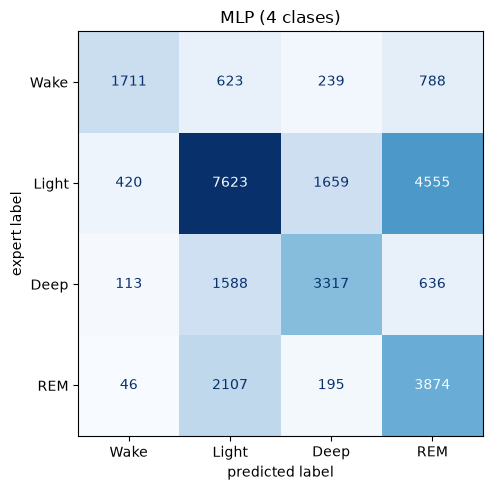

In [19]:
map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

y_true4, y_pred4 = remap(y_true), remap(y_pred)

print_metrics(y_true4, y_pred4, class_names=names4, name='MLP (4 clases)')

mask = dreem_test != 5
d4, p4 = remap(dreem_test[mask]), remap(y_pred[mask])
print(f"\nvs Dreem (4 clases)  ->  F1-macro: {f1_score(d4, p4, average='macro'):.3f}"
      f"   Kappa: {cohen_kappa_score(d4, p4):.3f}")

plot_confusion(y_true4, y_pred4, class_names=names4, title='MLP (4 clases)', save='mlp-confussion-4')
plt.show()

## Importancia de features (permutation importance)

El MLP no es interpretable directo como un árbol (no hay `feature_importance` ni SHAP fácil). Medimos la importancia por **permutación**: se baraja cada feature en el test y se mide cuánto **cae el Kappa**. Una caída grande = feature importante para el modelo. Es el análogo neuronal del análisis de importancia del XGBoost.

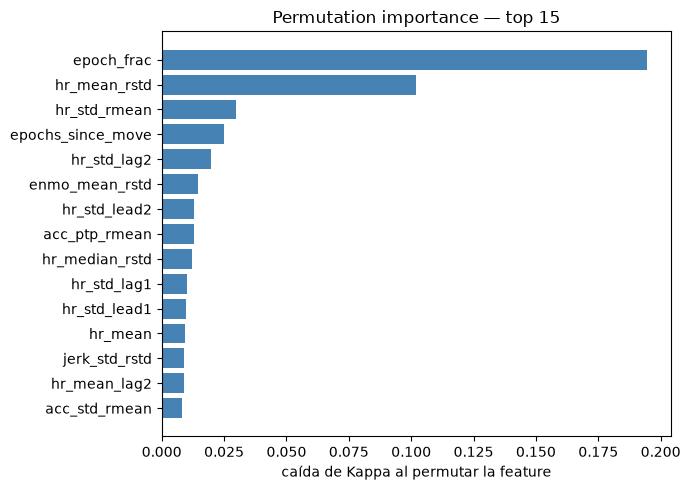

In [20]:
imp = permutation_importance(mlp, n_repeats=3, top=15)

feats = [f for f, _ in imp][::-1]
vals = [v for _, v in imp][::-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feats, vals, color='steelblue')
ax.set_xlabel('caída de Kappa al permutar la feature')
ax.set_title('Permutation importance — top 15')
plt.tight_layout(); plt.show()